# Week 2 - Backtest Report

Momentum vs. buy-and-hold across 7 assets (5 equities + 2 crypto), ~2016-2026.

Event-driven backtester with 5 bps commission and per-asset slippage (5 bps equities / 10 bps crypto). Momentum sizes at 20% of equity; buy-and-hold is fully invested.

In [1]:
import sys
sys.path.append("src")

from backtest import run_backtest, run_metrics
from load import show_ticker_list
import pandas as pd
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
tickers = show_ticker_list()
more_liquid = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA"]   # 252 bars/yr; crypto uses 365

normal_curves, bah_curves = {}, {}
normal_results, bah_results = {}, {}

for ticker in tickers:
    period = 252 if ticker in more_liquid else 365

    n_curve, n_dates = run_backtest(ticker, "normal")
    b_curve, b_dates = run_backtest(ticker, "buy_and_hold")

    normal_curves[ticker] = n_curve
    bah_curves[ticker]    = b_curve
    normal_results[ticker] = run_metrics(n_curve, n_dates, period)
    bah_results[ticker]    = run_metrics(b_curve, b_dates, period)

print("Ran:", list(normal_results.keys()))

Ran: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA', 'BTC-USD', 'ETH-USD']


## Performance summary

Momentum (Mom) vs. buy-and-hold (BAH), each metric side by side.

In [3]:
metric_keys = ["total_return", "annual_return", "max_drawdown", "sharpe", "calmar"]
labels = {"total_return": "Total %", "annual_return": "Annual %",
          "max_drawdown": "MaxDD %", "sharpe": "Sharpe", "calmar": "Calmar"}

rows = []
for ticker in tickers:
    row = {"Ticker": ticker}
    for k in metric_keys:
        row["Mom " + labels[k]] = round(float(normal_results[ticker][k]), 2)
        row["BAH " + labels[k]] = round(float(bah_results[ticker][k]), 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Ticker")
summary

,Mom Total %,BAH Total %,Mom Annual %,BAH Annual %,Mom MaxDD %,BAH MaxDD %,Mom Sharpe,BAH Sharpe,Mom Calmar,BAH Calmar
Ticker,,,,,,,,,,
SPY,-9.87,330.13,-1.03,15.71,10.86,33.91,-0.45,0.90,-0.10,0.46
QQQ,-17.74,643.56,-1.93,22.22,20.39,35.22,-0.63,1.01,-0.09,0.63
AAPL,-8.96,1297.56,-0.93,30.19,16.14,38.67,-0.22,1.06,-0.06,0.78
MSFT,-19.53,752.26,-2.15,23.90,21.71,37.20,-0.58,0.93,-0.10,0.64
NVDA,-8.54,17841.03,-0.89,68.05,22.49,66.38,-0.10,1.29,-0.04,1.03
BTC-USD,25.09,9153.93,2.26,57.23,22.79,83.40,0.36,1.01,0.10,0.69
ETH-USD,-17.17,413.81,-2.16,20.88,37.83,93.94,-0.14,0.65,-0.06,0.22


## Equity curves

Log y-axis, since the curves span orders of magnitude (buy-and-hold on NVDA runs from 100k to about 18M dollars).

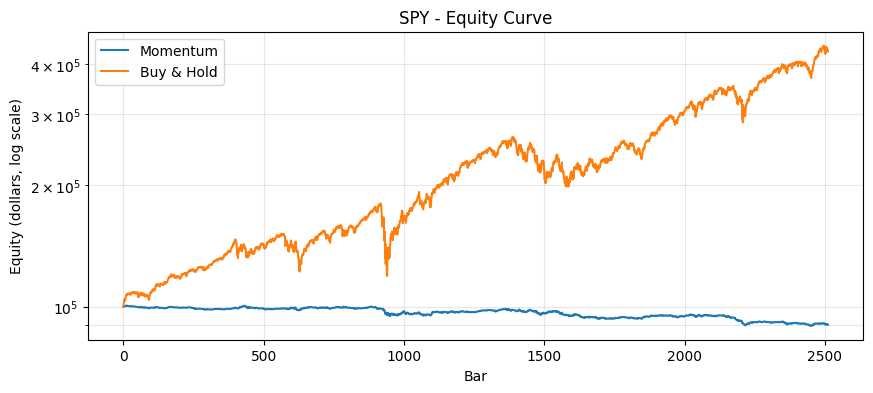

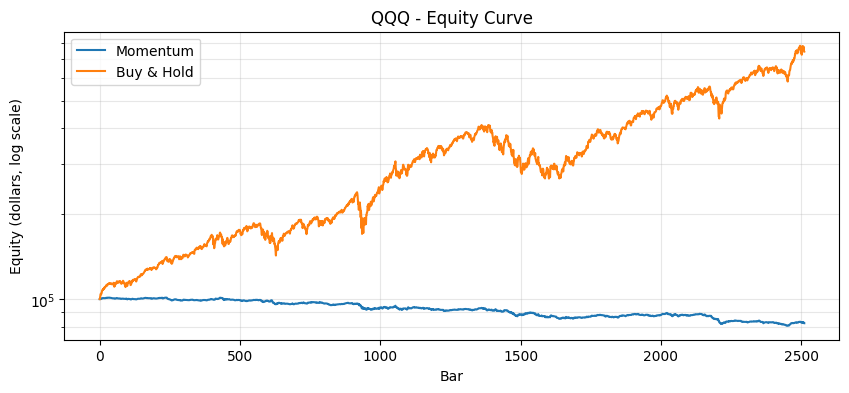

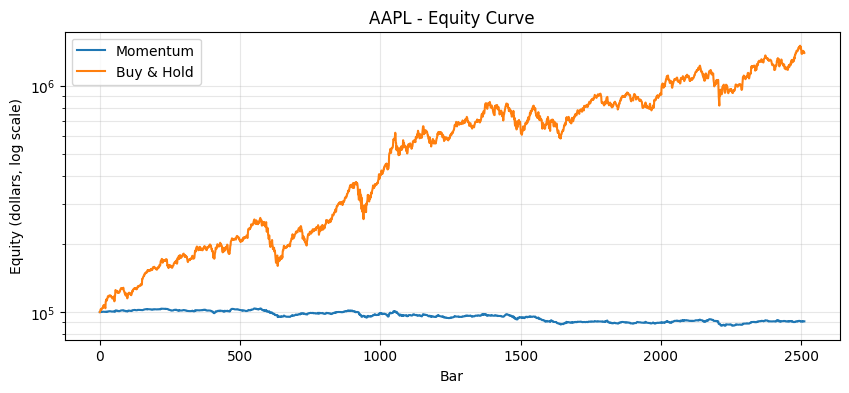

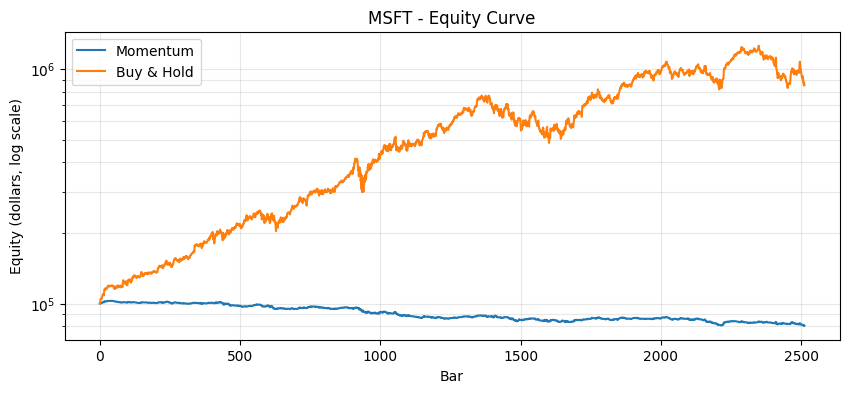

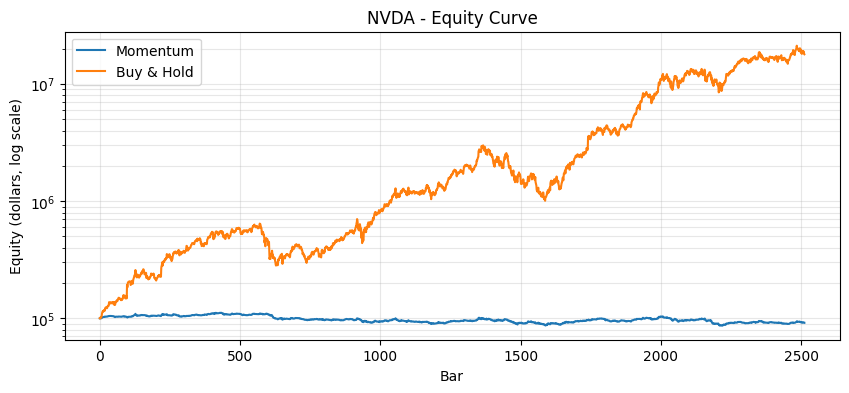

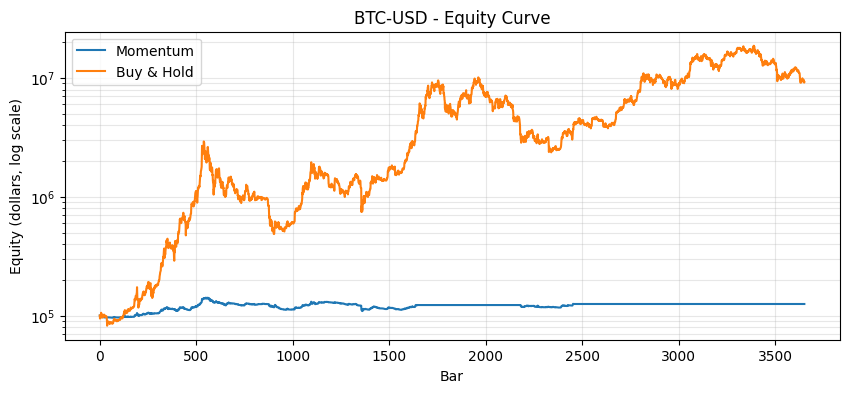

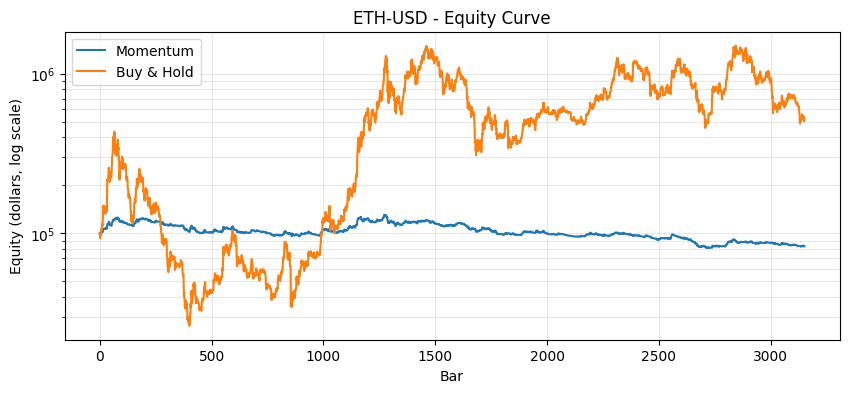

In [4]:
for ticker in tickers:
    plt.figure(figsize=(10, 4))
    plt.plot(normal_curves[ticker], label="Momentum")
    plt.plot(bah_curves[ticker], label="Buy & Hold")
    plt.yscale("log")
    plt.title(ticker + " - Equity Curve")
    plt.xlabel("Bar")
    plt.ylabel("Equity (dollars, log scale)")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

## What the numbers say

**Buy-and-hold wins on every single ticker, by huge margins.** Momentum total returns range from -19.5% (MSFT) to +25% (BTC); buy-and-hold ranges from +330% (SPY) to +17,841% (NVDA). The "do nothing" benchmark beats the active strategy everywhere.

**After realistic costs, momentum loses on 6 of 7 assets.** Even its one winner (BTC, +25%) is dwarfed by simply holding BTC (+9,151%). The naive up-day/down-day rule trades constantly, and 5 bps commission plus slippage on every flip compounds into a wrecking ball - a strategy that might look fine without costs is destroyed with them.

**The buy-and-hold numbers validate the engine.** Fully-invested buy-and-hold reproduces each asset's actual ~10-year price return (SPY ~= 4.3x, NVDA ~= 175x, BTC ~= 85x). Matching that independently-known answer confirms the fills, equity curve, costs, and metrics are all wired correctly end to end.

**Momentum's only edge is smaller drawdowns** - it sits out the crashes (NVDA 22% vs buy-and-hold 66%) - but it also sits out the recoveries and bleeds costs, so it loses overall. Buy-and-hold's returns come with brutal drawdowns (ETH -94%, BTC -83%): the real risk taken for the return.

**Conclusion:** the toy momentum rule has no edge after costs. That is the backtester doing its job honestly, and it sets the bar the real strategy (momentum gated by autocorrelation + volatility) will have to clear: not "profitable on paper", but profitable *after it pays to trade*.